# Figures for the paper

Only the plots used in the paper. Each is saved as a separate high-resolution PNG with a transparent
background (filtered-away pixels are transparent too) in `FIG_DIR`, a subfolder of the process folder;
the figures themselves are assembled in Inkscape.

Every panel is also saved as SVG with editable text in `PAPER_DIR` (`visualization/figures/`, not version
controlled), together with the two assembled figures, `ipf_maps.svg` and `misorientation_figure.svg`.

**Figure A**: IPF-Y map (with scale bar), IPF-Z map, IPF colour key.

**Figure B**: KAM map + separate colourbar, grey inverse pole figures of the orientations in one pixel
(`IPF_PIXEL`), histogram of the misorientation from the medoid in another pixel (`HIST_PIXEL`).

IPF-Y, IPF-Z and the KAM maps are saved on one shared canvas (same size and scale, with a transparent strip
below the map for the scale bar), so they overlay exactly in Inkscape and the scale bar on IPF-Y holds for all.

Orientation convention: `grid_mats` are ImageD11 `U` matrices (crystal -> lab), and orix needs `U.T`, as in
`texture_tomography/textomo_*.ipynb`. Checked with a `U` that puts [111] along lab Z: it is coloured blue in
IPF-Z only with the transpose. All misorientation angles are computed with orix on the same orientations, so
the crystal symmetry is applied on the correct side.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
from pathlib import Path

# make the repository importable, whatever the working directory is
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "integration" / "frame_loader.py").is_file())
sys.path.insert(0, str(REPO))

import os
import time

import h5py
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from orix import plot as orix_plot
from orix.quaternion import Orientation, symmetry
from orix.vector import Vector3d

from integration.frame_loader import PROCESS
from integration.integrated_data import IntegratedData

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Palatino", "Georgia"],
    "font.size": 14,
})

## Parameters

In [2]:
GRID = "adaptive"  # which reconstruction: "adaptive" or "uniform"
RECON_PATH = os.path.join(PROCESS, f"reconstruction_{GRID}.h5")
FIG_DIR = os.path.join(PROCESS, "figures", GRID)
DPI = 600
# SVG panels and the assembled figures, with text kept as text for Inkscape
PAPER_DIR = os.path.join(REPO, "visualization", "figures")

# pixels whose total density is below MASK_FRACTION x (99th percentile) are filtered away (transparent)
MASK_FRACTION = 0.3
# the outermost EDGE_CROP pixels on every side are always filtered (reconstruction edge artifacts)
EDGE_CROP = 5

# weighted medoid per pixel, searched among the TOP_K most weighted orientations
TOP_K = 24

# maps (IPF-Y, IPF-Z, KAM) share one canvas: same size and scale, with a transparent strip of
# MAP_MARGIN (fraction of the map height) below the map, which holds the scale bar on IPF-Y
MAP_WIDTH_IN = 6.0
MAP_MARGIN = 0.12
SCALE_BAR_UM = 200
SCALE_BAR_LABEL = True

# KAM colour scale: log(KAM_LOG_EPS + KAM) up to KAM_VMAX_DEG
KAM_VMAX_DEG = 50.0
KAM_LOGSCALE = True
KAM_LOG_EPS = 4.0

# the two pixels of Figure B, as (row, col) in the maps as displayed (see 'Picking the two pixels' below)
IPF_PIXEL = (48, 25)   # grey inverse pole figures (green marker)
HIST_PIXEL = (75, 55)  # misorientation histogram (red marker)

# grey inverse pole figures
IPF_DIRECTIONS = {"z": [0, 0, 1], "y": [0, 1, 0], "x": [1, 0, 0]}
IPF_POINT_SIZE = (10, 80)  # marker size for the smallest / largest weight
IPF_ALPHA = (0.25, 1.0)
IPF_GREY = (0.25, 0.25, 0.25)

# misorientation histogram
HIST_N_BINS = 40
HIST_XMAX_DEG = 15
HIST_COLOR = "#d62728"

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(PAPER_DIR, exist_ok=True)
plt.rcParams["svg.fonttype"] = "none"
print(f"reading {RECON_PATH}\nwriting to {FIG_DIR}")

reading /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/reconstruction_adaptive.h5
writing to /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/adaptive


## Load the reconstruction

In [3]:
with h5py.File(RECON_PATH, "r") as f:
    x = f["coeffs"][...]  # (K, Ny, Nx), as saved by textomo_*.ipynb: x[k] is the image of orientation k
    # per pixel, in the map orientation of the figures: (Nx, Ny, K) with the first axis flipped
    coeffs = x.transpose(2, 1, 0)[::-1].astype(np.float64)
    grid_mats = f["grid_mats"][...]               # (K, 3, 3)
    recon_attrs = dict(f.attrs)
Ny, Nx, K = coeffs.shape
print(f"coeffs {coeffs.shape}; attrs: { {k: recon_attrs[k] for k in ('grid', 'K', 'sigma_deg', 'niter') if k in recon_attrs} }")

# pixel size = translation step of the integrated data the reconstruction was made from
data = IntegratedData(recon_attrs["data"])
unique_positions = np.unique(np.round(data.translations, 4))
pixel_um = float(np.median(np.diff(unique_positions))) * 1e3  # dty in mm
print(f"pixel size: {pixel_um:.2f} um")

orientations = Orientation.from_matrix(np.transpose(grid_mats, (0, 2, 1)), symmetry.Oh)
extent_um = (0, Nx * pixel_um, Ny * pixel_um, 0)

coeffs (115, 115, 48017); attrs: {'grid': 'adaptive', 'K': np.int64(48017), 'sigma_deg': np.float64(0.4), 'niter': np.int64(200)}
pixel size: 10.00 um


## Filtered pixels
The red contour is the kept region; everything outside it is transparent in the saved maps.

kept 8486 of 13225 pixels


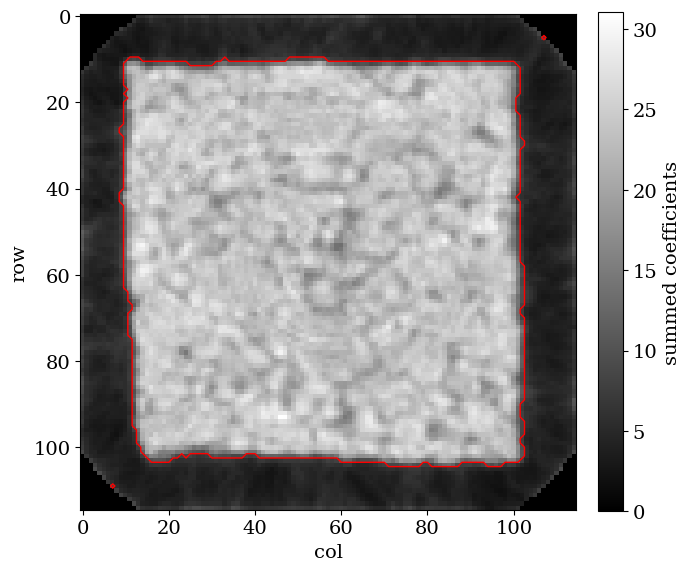

In [4]:
density = coeffs.sum(axis=-1)
keep = density > MASK_FRACTION * np.percentile(density, 99)
if EDGE_CROP > 0:
    keep[:EDGE_CROP] = keep[-EDGE_CROP:] = False
    keep[:, :EDGE_CROP] = keep[:, -EDGE_CROP:] = False
print(f"kept {keep.sum()} of {keep.size} pixels")

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(density, cmap="gray")
ax.contour(keep, levels=[0.5], colors="r", linewidths=1)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="summed coefficients")
ax.set_xlabel("col"); ax.set_ylabel("row")
plt.show()

## Medoid orientation per pixel
The orientation among the `TOP_K` most weighted ones that minimises the weighted sum of misorientations to the others.

In [5]:
def weighted_medoid(weights):
    """Index (into grid_mats) of the weighted medoid of one pixel's orientation distribution."""
    top = np.argsort(weights)[-TOP_K:]
    top = top[weights[top] > 0]
    if len(top) <= 1:
        return int(np.argmax(weights))
    angles = orientations[top].angle_with_outer(orientations[top])  # (n, n), symmetry reduced, radians
    return int(top[np.argmin(angles @ weights[top])])

t0 = time.perf_counter()
medoid_idx = np.full((Ny, Nx), -1)
for iy, ix in zip(*np.nonzero(keep)):
    medoid_idx[iy, ix] = weighted_medoid(coeffs[iy, ix])
print(f"medoids of {keep.sum()} pixels in {time.perf_counter() - t0:.0f} s")

medoids of 8486 pixels in 25 s


## Figure A: IPF-Y and IPF-Z maps, colour key

map canvas: 3600 px wide = 1150 um, i.e. 3.13 px per um


saved /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/adaptive/ipf_y.png
saved /zhome/71/c/146676/texture_tomography/visualization/figures/ipf_y.svg


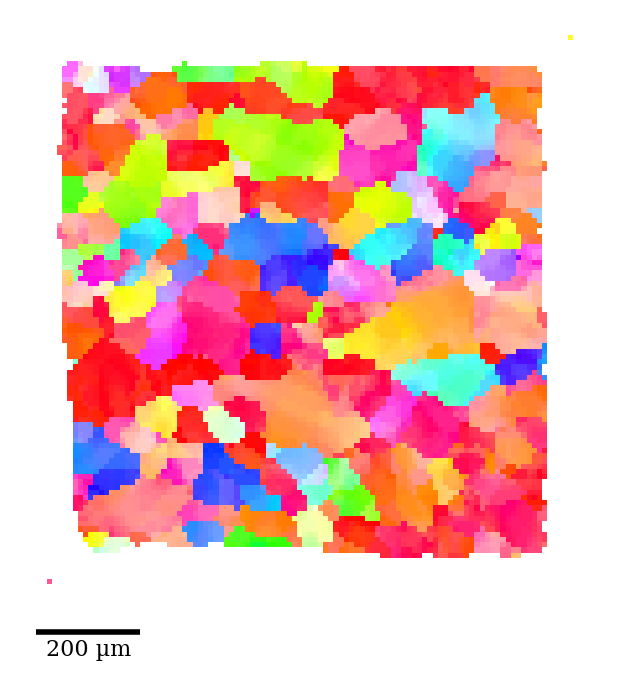

saved /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/adaptive/ipf_z.png
saved /zhome/71/c/146676/texture_tomography/visualization/figures/ipf_z.svg


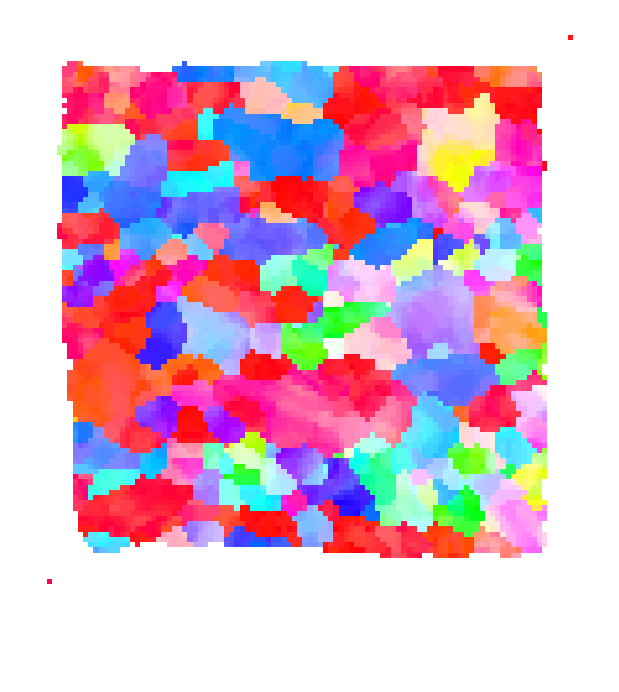

saved /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/adaptive/ipf_color_key.png


saved /zhome/71/c/146676/texture_tomography/visualization/figures/ipf_color_key.svg


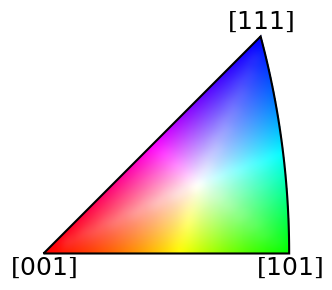

In [6]:
def ipf_rgba(direction):
    key = orix_plot.IPFColorKeyTSL(symmetry.Oh, direction=Vector3d(direction))
    rgba = np.zeros((Ny, Nx, 4))
    rgba[keep, :3] = key.orientation2color(orientations[medoid_idx[keep]])
    rgba[keep, 3] = 1.0  # filtered pixels stay fully transparent
    return rgba


W_UM, H_UM = Nx * pixel_um, Ny * pixel_um


def crisp(image, factor=8):
    """Repeat every pixel factor x factor times, so the pixels stay sharp squares in any SVG viewer."""
    return np.repeat(np.repeat(image, factor, axis=0), factor, axis=1)


def map_figure():
    """Canvas shared by all maps: axes fill the figure, map on top, transparent strip below."""
    h_total = H_UM * (1 + MAP_MARGIN)
    fig = plt.figure(figsize=(MAP_WIDTH_IN, MAP_WIDTH_IN * h_total / W_UM))
    ax = fig.add_axes([0, 0, 1, 1])
    ax.axis("off")
    return fig, ax


def finish_map(ax):
    ax.set_xlim(0, W_UM)
    ax.set_ylim(H_UM * (1 + MAP_MARGIN), 0)


def add_scale_bar(ax):
    x0, y = EDGE_CROP * pixel_um, H_UM * (1 + 0.3 * MAP_MARGIN)
    ax.plot([x0, x0 + SCALE_BAR_UM], [y, y], lw=4, color="black", solid_capstyle="butt")
    if SCALE_BAR_LABEL:
        ax.text(x0 + SCALE_BAR_UM / 2, y + 0.1 * MAP_MARGIN * H_UM, f"{SCALE_BAR_UM:g} µm",
                ha="center", va="top", fontsize=16)


def save_map(fig, name):
    """Maps: whole canvas, no cropping, so every map has the same size and scale. PNG in FIG_DIR, SVG in PAPER_DIR."""
    for path in [os.path.join(FIG_DIR, name), os.path.join(PAPER_DIR, Path(name).with_suffix(".svg"))]:
        fig.savefig(path, dpi=DPI, transparent=True)
        print(f"saved {path}")


def save_fig(fig, name):
    """Everything else: cropped to its content. PNG in FIG_DIR, SVG in PAPER_DIR."""
    for path in [os.path.join(FIG_DIR, name), os.path.join(PAPER_DIR, Path(name).with_suffix(".svg"))]:
        fig.savefig(path, dpi=DPI, transparent=True, bbox_inches="tight", pad_inches=0.05)
        print(f"saved {path}")


print(f"map canvas: {MAP_WIDTH_IN * DPI:.0f} px wide = {W_UM:.0f} um, i.e. {MAP_WIDTH_IN * DPI / W_UM:.2f} px per um")
for label, direction, scale_bar in [("y", [0, 1, 0], True), ("z", [0, 0, 1], False)]:
    fig, ax = map_figure()
    ax.imshow(crisp(ipf_rgba(direction)), extent=(0, W_UM, H_UM, 0), interpolation="none")
    if scale_bar:
        add_scale_bar(ax)
    finish_map(ax)
    save_map(fig, f"ipf_{label}.png")
    plt.show()

fig = plt.figure(figsize=(4, 3))
ax = fig.add_subplot(projection="ipf", symmetry=symmetry.Oh)
ax.plot_ipf_color_key(show_title=False)
ax.patch.set_facecolor("none")
save_fig(fig, "ipf_color_key.png")
plt.show()

## Figure B: KAM map and colourbar
KAM = mean misorientation between a pixel's medoid and the medoids of its (up to 4) kept neighbours.

KAM: median 1.75 deg, 99th percentile 29.76 deg


saved /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/adaptive/kam_map.png
saved /zhome/71/c/146676/texture_tomography/visualization/figures/kam_map.svg


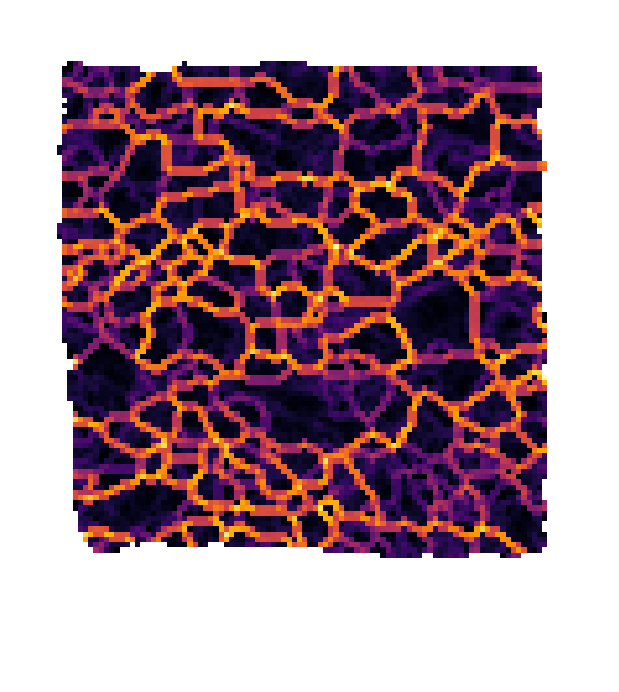

saved /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/adaptive/kam_map_marked.png
saved /zhome/71/c/146676/texture_tomography/visualization/figures/kam_map_marked.svg


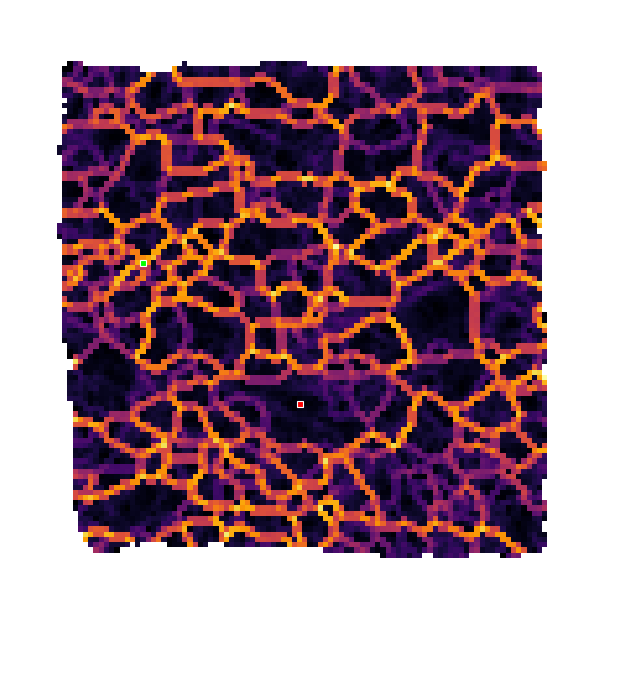

saved /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/adaptive/kam_colorbar.png
saved /zhome/71/c/146676/texture_tomography/visualization/figures/kam_colorbar.svg


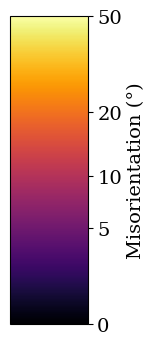

In [7]:
medoid_oris = orientations[medoid_idx.clip(0)]  # (Ny, Nx); meaningful only where keep
kam_sum = np.zeros((Ny, Nx))
kam_count = np.zeros((Ny, Nx))
for a, b in [((slice(None), slice(0, -1)), (slice(None), slice(1, None))),   # right neighbour
             ((slice(0, -1), slice(None)), (slice(1, None), slice(None)))]:  # lower neighbour
    pair = keep[a] & keep[b]
    ang = medoid_oris[a][pair].angle_with(medoid_oris[b][pair], degrees=True)
    for s in (a, b):
        kam_sum[s][pair] += ang
        kam_count[s][pair] += 1
kam = np.where(kam_count > 0, kam_sum / np.maximum(kam_count, 1), np.nan)
kam[~keep] = np.nan
print(f"KAM: median {np.nanmedian(kam):.2f} deg, 99th percentile {np.nanpercentile(kam, 99):.2f} deg")

if KAM_LOGSCALE:
    kam_plot = np.log(KAM_LOG_EPS + np.clip(kam, 0, KAM_VMAX_DEG))
    vmin, vmax = np.log(KAM_LOG_EPS), np.log(KAM_LOG_EPS + KAM_VMAX_DEG)

    def nice(v):
        e = np.floor(np.log10(v)); f = v / 10 ** e
        return (1 if f < 1.5 else 2 if f < 3.5 else 5 if f < 7.5 else 10) * 10 ** e

    raw = np.exp(np.linspace(vmin, vmax, 5)) - KAM_LOG_EPS
    tick_deg = np.array([0.0] + [nice(v) for v in raw[1:-1]] + [KAM_VMAX_DEG])
    tick_pos = np.log(KAM_LOG_EPS + tick_deg)
else:
    kam_plot = np.clip(kam, 0, KAM_VMAX_DEG)
    vmin, vmax = 0.0, KAM_VMAX_DEG
    tick_deg = tick_pos = np.linspace(0, KAM_VMAX_DEG, 5)

KAM_CMAP = "inferno"  # NaN (filtered) pixels are drawn transparent
for name, marked in [("kam_map.png", False), ("kam_map_marked.png", True)]:
    fig, ax = map_figure()
    ax.imshow(crisp(kam_plot), cmap=KAM_CMAP, vmin=vmin, vmax=vmax, extent=(0, W_UM, H_UM, 0), interpolation="none")
    if marked:
        for (r, c), color in [(IPF_PIXEL, "#00ff00"), (HIST_PIXEL, "red")]:
            ax.plot((c + 0.5) * pixel_um, (r + 0.5) * pixel_um, "s", ms=4, mfc=color, mec="white", mew=0.8)
    finish_map(ax)
    save_map(fig, name)
    plt.show()

fig, ax = plt.subplots(figsize=(1.0, 4.0))
cb = matplotlib.colorbar.ColorbarBase(ax, cmap=plt.get_cmap(KAM_CMAP),
                                      norm=mcolors.Normalize(vmin=vmin, vmax=vmax), orientation="vertical")
cb.set_ticks(tick_pos)
cb.set_ticklabels([f"{v:.3g}" for v in tick_deg])
cb.set_label("Misorientation (°)")
save_fig(fig, "kam_colorbar.png")
plt.show()

### Picking the two pixels
KAM map with row/column axes, to choose `IPF_PIXEL` (green) and `HIST_PIXEL` (red). Display only, not saved.

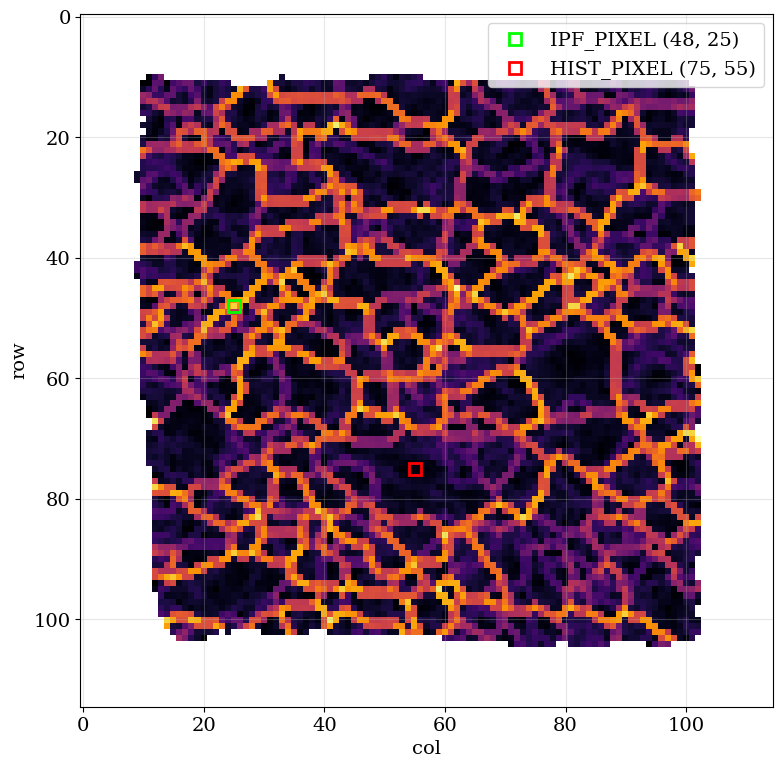

In [8]:
fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(kam_plot, cmap=KAM_CMAP, vmin=vmin, vmax=vmax, interpolation="nearest")
for (r, c), color, label in [(IPF_PIXEL, "#00ff00", "IPF_PIXEL"), (HIST_PIXEL, "red", "HIST_PIXEL")]:
    ax.plot(c, r, "s", ms=8, mfc="none", mec=color, mew=2, label=f"{label} {r, c}")
ax.set_xlabel("col"); ax.set_ylabel("row")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.show()
for name, (r, c) in [("IPF_PIXEL", IPF_PIXEL), ("HIST_PIXEL", HIST_PIXEL)]:
    assert keep[r, c], f"{name} {r, c} is a filtered-away pixel"

## Figure B: grey inverse pole figures of `IPF_PIXEL`
Every orientation with positive weight; marker size and opacity scale with its weight.

IPF_PIXEL (48, 25): 1361 orientations with positive weight


saved /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/adaptive/ipf_pixel_z.png
saved /zhome/71/c/146676/texture_tomography/visualization/figures/ipf_pixel_z.svg


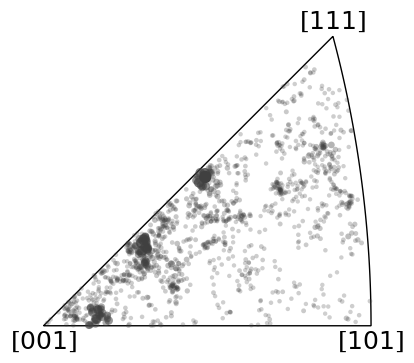

saved /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/adaptive/ipf_pixel_y.png
saved /zhome/71/c/146676/texture_tomography/visualization/figures/ipf_pixel_y.svg


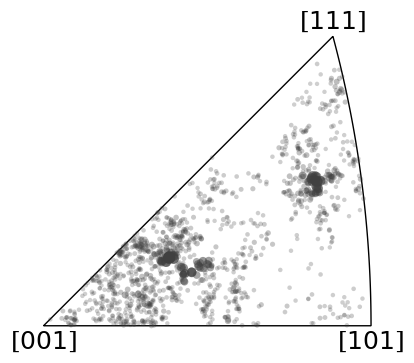

saved /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/adaptive/ipf_pixel_x.png
saved /zhome/71/c/146676/texture_tomography/visualization/figures/ipf_pixel_x.svg


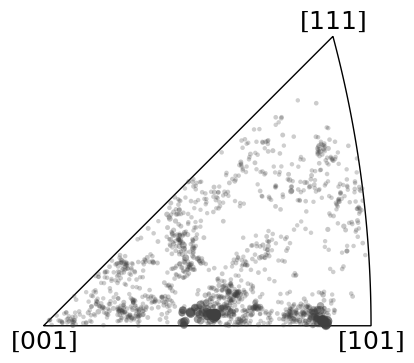

In [9]:
w = coeffs[IPF_PIXEL]
pos = np.flatnonzero(w > 0)
w_norm = w[pos] / w[pos].max()
order = np.argsort(w_norm)  # heaviest drawn last
sizes = IPF_POINT_SIZE[0] + (IPF_POINT_SIZE[1] - IPF_POINT_SIZE[0]) * w_norm[order]
alphas = IPF_ALPHA[0] + (IPF_ALPHA[1] - IPF_ALPHA[0]) * w_norm[order]
rgba = np.column_stack([np.tile(IPF_GREY, (len(order), 1)), alphas])
print(f"IPF_PIXEL {IPF_PIXEL}: {len(pos)} orientations with positive weight")

for label, direction in IPF_DIRECTIONS.items():
    fig = plt.figure(figsize=(5, 4))
    ax = fig.add_subplot(projection="ipf", symmetry=symmetry.Oh, direction=Vector3d(direction))
    ax.scatter(orientations[pos[order]], c=rgba, s=sizes, edgecolors="none", zorder=2)
    ax.set_facecolor("white")
    save_fig(fig, f"ipf_pixel_{label}.png")
    plt.show()

## Figure B: misorientation from the medoid in `HIST_PIXEL`
Weighted histogram of the misorientation between every orientation with positive weight and the pixel's weighted medoid, normalised to unit area.

HIST_PIXEL (75, 55): 1413 orientations; weight beyond 15 deg: 22.1%


saved /dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/adaptive/misorientation_histogram.png
saved /zhome/71/c/146676/texture_tomography/visualization/figures/misorientation_histogram.svg


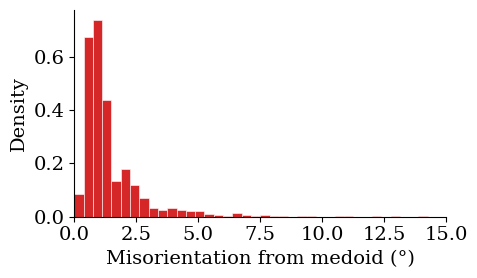

In [10]:
w = coeffs[HIST_PIXEL]
pos = np.flatnonzero(w > 0)
medoid = orientations[weighted_medoid(w)]
misori = orientations[pos].angle_with_outer(medoid, degrees=True).ravel()

bin_edges = np.linspace(0, HIST_XMAX_DEG, HIST_N_BINS + 1)
hist, _ = np.histogram(misori, bins=bin_edges, weights=w[pos])
density_hist = hist / (hist.sum() * np.diff(bin_edges))
print(f"HIST_PIXEL {HIST_PIXEL}: {len(pos)} orientations; weight beyond {HIST_XMAX_DEG} deg: "
      f"{w[pos][misori > HIST_XMAX_DEG].sum() / w[pos].sum():.1%}")

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(bin_edges[:-1], density_hist, width=np.diff(bin_edges), align="edge",
       color=HIST_COLOR, edgecolor="white", linewidth=0.4)
ax.set_xlim(0, HIST_XMAX_DEG)
ax.set_xlabel("Misorientation from medoid (°)")
ax.set_ylabel("Density")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
save_fig(fig, "misorientation_histogram.png")
plt.show()

## Assembled figures (SVG)
The two paper figures, assembled from the same plots as above and saved in `PAPER_DIR`:

- `ipf_maps.svg`: IPF-Y map with scale bar, IPF-Z map and the IPF colour key;
- `misorientation_figure.svg`: KAM map with colour bar and scale bar, the IPF-X of `IPF_PIXEL` (green box)
  and the misorientation histogram of `HIST_PIXEL` (red box), each connected to its pixel.

saved /zhome/71/c/146676/texture_tomography/visualization/figures/ipf_maps.svg


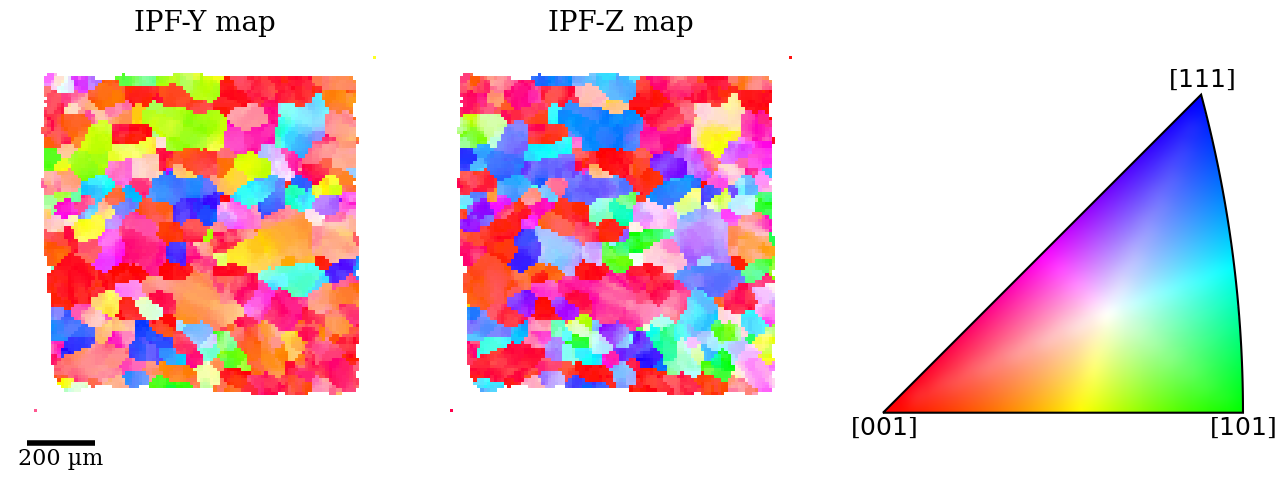

In [11]:
def draw_map(ax, image, **kw):
    ax.imshow(crisp(image), extent=(0, W_UM, H_UM, 0), interpolation="none", **kw)
    ax.axis("off")
    finish_map(ax)


def save_paper(fig, name):
    path = os.path.join(PAPER_DIR, name)
    fig.savefig(path, dpi=DPI, transparent=True, bbox_inches="tight", pad_inches=0.05)
    print(f"saved {path}")


# Figure A: IPF-Y, IPF-Z, colour key
map_h = 0.80                                    # map axes height (figure fraction)
fig = plt.figure(figsize=(13, 13 * 0.42))
fig_w, fig_h = fig.get_size_inches()
map_w = map_h * fig_h / fig_w * W_UM / (H_UM * (1 + MAP_MARGIN))  # keep the map aspect
for n, (label, direction) in enumerate([("Y", [0, 1, 0]), ("Z", [0, 0, 1])]):
    ax = fig.add_axes([0.01 + n * (map_w + 0.02), 0.02, map_w, map_h])
    draw_map(ax, ipf_rgba(direction))
    if label == "Y":
        add_scale_bar(ax)
    ax.set_title(f"IPF-{label} map", fontsize=20)
ax = fig.add_axes([0.02 + 2 * (map_w + 0.02), 0.12, 0.98 - 2 * (map_w + 0.02) - 0.02, 0.62],
                  projection="ipf", symmetry=symmetry.Oh)
ax.plot_ipf_color_key(show_title=False)
ax.patch.set_facecolor("none")
save_paper(fig, "ipf_maps.svg")
plt.show()

saved /zhome/71/c/146676/texture_tomography/visualization/figures/misorientation_figure.svg


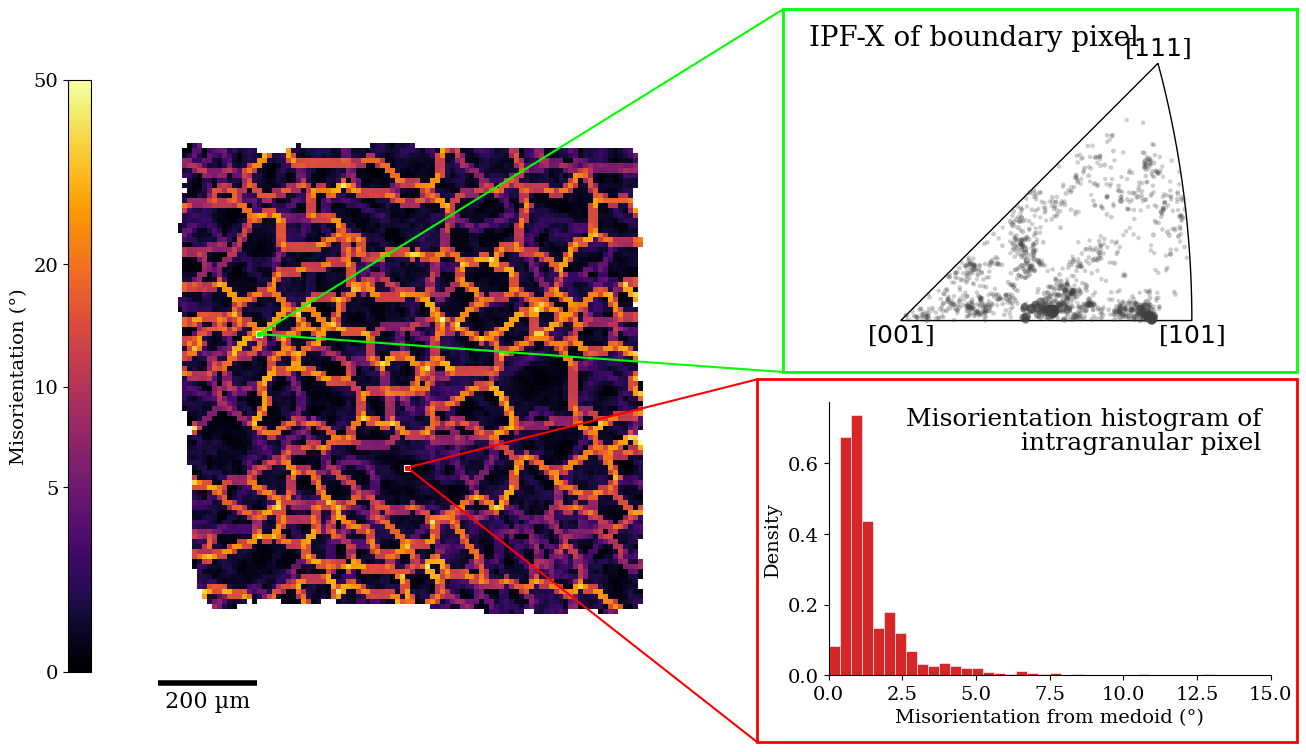

In [12]:
from matplotlib.patches import ConnectionPatch, Rectangle

PIXEL_COLORS = {"ipf": "#00ff00", "hist": "red"}

fig = plt.figure(figsize=(13, 7.4))
# colour bar and KAM map on the left
cax = fig.add_axes([0.05, 0.10, 0.018, 0.80])
map_h = 0.86
map_w = map_h * 7.4 / 13 * W_UM / (H_UM * (1 + MAP_MARGIN))
ax_map = fig.add_axes([0.10, 0.02, map_w, map_h])
draw_map(ax_map, kam_plot, cmap=KAM_CMAP, vmin=vmin, vmax=vmax)
add_scale_bar(ax_map)
cb = matplotlib.colorbar.ColorbarBase(cax, cmap=plt.get_cmap(KAM_CMAP),
                                      norm=mcolors.Normalize(vmin=vmin, vmax=vmax), orientation="vertical")
cb.set_ticks(tick_pos)
cb.set_ticklabels([f"{v:.3g}" for v in tick_deg])
cb.set_label("Misorientation (°)")
cb.ax.yaxis.set_ticks_position("left")
cb.ax.yaxis.set_label_position("left")

# boxes on the right: (left, bottom, width, height) in figure fractions
box_ipf = (0.60, 0.505, 0.395, 0.49)
box_hist = (0.58, 0.005, 0.415, 0.49)

# grey IPF-X of IPF_PIXEL
w = coeffs[IPF_PIXEL]
pos = np.flatnonzero(w > 0)
w_norm = w[pos] / w[pos].max()
order = np.argsort(w_norm)
sizes = IPF_POINT_SIZE[0] + (IPF_POINT_SIZE[1] - IPF_POINT_SIZE[0]) * w_norm[order]
alphas = IPF_ALPHA[0] + (IPF_ALPHA[1] - IPF_ALPHA[0]) * w_norm[order]
rgba = np.column_stack([np.tile(IPF_GREY, (len(order), 1)), alphas])
l, b, wd, ht = box_ipf
ax_ipf = fig.add_axes([l + 0.04, b + 0.06, wd - 0.07, ht - 0.12], projection="ipf",
                      symmetry=symmetry.Oh, direction=Vector3d(IPF_DIRECTIONS["x"]))
ax_ipf.scatter(orientations[pos[order]], c=rgba, s=sizes, edgecolors="none", zorder=2)
fig.text(l + 0.02, b + ht - 0.02, "IPF-X of boundary pixel", ha="left", va="top", fontsize=20)

# misorientation histogram of HIST_PIXEL (same computation as the panel above)
l, b, wd, ht = box_hist
ax_hist = fig.add_axes([l + 0.055, b + 0.09, wd - 0.075, ht - 0.12])
ax_hist.bar(bin_edges[:-1], density_hist, width=np.diff(bin_edges), align="edge",
            color=HIST_COLOR, edgecolor="white", linewidth=0.4)
ax_hist.set_xlim(0, HIST_XMAX_DEG)
ax_hist.set_xlabel("Misorientation from medoid (°)")
ax_hist.set_ylabel("Density")
ax_hist.spines[["top", "right"]].set_visible(False)
ax_hist.text(0.98, 0.98, "Misorientation histogram of\nintragranular pixel", transform=ax_hist.transAxes,
             ha="right", va="top", fontsize=18, linespacing=1.1)

# boxes, pixel markers and connecting lines
for (r, c), box, color in [(IPF_PIXEL, box_ipf, PIXEL_COLORS["ipf"]), (HIST_PIXEL, box_hist, PIXEL_COLORS["hist"])]:
    l, b, wd, ht = box
    fig.add_artist(Rectangle((l, b), wd, ht, transform=fig.transFigure, fill=False, edgecolor=color, linewidth=2))
    xy = ((c + 0.5) * pixel_um, (r + 0.5) * pixel_um)
    ax_map.plot(*xy, "s", ms=4, mfc=color, mec="white", mew=0.8)
    for corner in [(l, b), (l, b + ht)]:
        fig.add_artist(ConnectionPatch(xyA=xy, coordsA=ax_map.transData, xyB=corner, coordsB=fig.transFigure,
                                       color=color, linewidth=1.5))
save_paper(fig, "misorientation_figure.svg")
plt.show()

In [13]:
for p in sorted(Path(FIG_DIR).glob("*.png")):
    print(p)

/dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/adaptive/ipf_color_key.png
/dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/adaptive/ipf_pixel_x.png
/dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/adaptive/ipf_pixel_y.png
/dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/adaptive/ipf_pixel_z.png
/dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/adaptive/ipf_y.png
/dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/adaptive/ipf_z.png
/dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/adaptive/kam_colorbar.png
/dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/2025_Danmax_Al1050/process/figures/ad